In [22]:
import os
import cv2
import torch
import numpy as np 
import pandas as pd 
import matplotlib
import matplotlib.pyplot as plt 
from matplotlib.patches import Rectangle
from tqdm import tqdm

import snntorch as snn
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

# clean gpu memory when starting a new evaluation.
torch.cuda.empty_cache()

GPU_DEVICE = 3
os.environ['CUDA_VISIBLE_DEVICES'] = str(GPU_DEVICE)

assert torch.cuda.is_available()

In [2]:
DATA_PATH = 'data/events_converted_from_3D_models/mug'
event_lst = sorted([f for f in os.listdir(DATA_PATH) if '.npy' in f])
RES = (260, 356)

In [3]:
from PIL import Image

def create_gif(images, output_gif_path, duration=100):
     images = [Image.fromarray(np.stack([img, img, img], axis=-1)) for img in images]
     # Save as GIF
     images[0].save(output_gif_path,
                    save_all=True,
                    append_images=images[1:],
                    duration=duration,
                    loop=0 # 0 means infinite loop
                    )

test = np.load(os.path.join(DATA_PATH, event_lst[0]))
frames = np.zeros((35, *RES))

all_times = []
for t in test:
    x, y, pol, time = t 
    
    all_times.append(time // 1000)
    t = time // 1000 
    frames[t, y, x] = pol if pol > 0 else 0.5
    
frames = frames * 255
create_gif(frames.astype(np.uint8), 'test.gif')

## Read CALTECH 256

```python
%%time
import h5py

filename = "data/INI_Caltech256_10fps_20160424.hdf5"
data_lst = []
with h5py.File(filename, "r") as f:

    #f.visit(print)  
    object_keys = f.keys()
    for k in object_keys:
        sample_lst = f[k].keys()
        
        for s in sample_lst:
            data_x = f[k][s]['x_pos'][:]
            data_y = f[k][s]['y_pos'][:]
            data_t = f[k][s]['timestamps'][:]
            data_pol = f[k][s]['pol'][:]
            
            data = {'object': k, 'sample': s, 'x_pos': data_x, 'y_pos': data_y, 
                    'timestamps': data_t, 'pol': data_pol}
            data_lst.append(data)
        
    
df = pd.DataFrame.from_records(data_lst)
df['category'] = df.apply(lambda x: int(x['object'].split('.')[0]), axis=1)
df['label'] = df.apply(lambda x: str(x['object'].split('.')[1]), axis=1)
df['sample'] = df['sample'].map(lambda x: int(x.split('_')[-1]))
del df['object']
df.to_pickle('Caltech_256_DVS.pkl')
df.head() 
```

In [82]:
df = pd.read_pickle('Caltech_256_DVS.pkl')
print('Number of samples: ', len(df))
df.head()

Number of samples:  30607


,sample,x_pos,y_pos,timestamps,pol,category,label
0,1,"[192, 146, 106, 37, 140, 80, 87, 173, 146, 187...","[109, 71, 29, 101, 36, 143, 135, 88, 50, 153, ...","[288080, 288235, 288387, 288692, 289515, 28971...","[True, True, True, True, True, True, True, Tru...",1,ak47
1,2,"[152, 149, 224, 76, 80, 63, 213, 38, 214, 135,...","[53, 116, 18, 114, 8, 173, 102, 23, 104, 28, 3...","[299585, 301461, 301791, 304118, 304755, 30783...","[True, True, True, True, True, True, True, Tru...",1,ak47
2,3,"[80, 128, 94, 57, 113, 105, 91, 96, 166, 93, 1...","[144, 40, 149, 37, 62, 44, 59, 32, 89, 142, 12...","[299761, 299961, 300369, 300463, 300466, 30046...","[True, True, True, True, True, True, True, Tru...",1,ak47
3,4,"[208, 40, 94, 191, 104, 158, 126, 138, 48, 214...","[97, 142, 137, 96, 136, 29, 56, 147, 75, 121, ...","[301202, 302304, 302330, 304919, 304952, 30559...","[True, True, True, True, True, True, True, Tru...",1,ak47
4,5,"[108, 154, 220, 162, 215, 124, 132, 86, 220, 2...","[122, 179, 84, 126, 31, 135, 155, 104, 12, 73,...","[286731, 286909, 288470, 291223, 291830, 29219...","[True, True, True, True, True, True, True, Tru...",1,ak47


In [87]:
idx = 6210 
data = df.iloc[idx]

frames = np.zeros(((max(data.timestamps) // 30000) +1, 180, 240))
for (x, y, pol, time) in zip(data.x_pos, data.y_pos, data.pol, data.timestamps): 
    
    t = time // 30000  
    frames[t, y, x] = pol 
    
frames = frames * 255
create_gif(frames.astype(np.uint8), f'caltech256-{idx}.gif')

In [74]:
class CaltechDataset(Dataset):
    """Caltech 256 DVS Dataset for object recognition"""

    def __init__(self, dataset, img_size=(180, 240), max_t=35, transform=None):
        
        self.dataset = dataset
        self.img_size = img_size
        self.max_t = max_t
        self.dimension = img_size[0] * img_size[1]
        self.pos_id = np.arange(img_size[0] * img_size[1]).reshape(img_size[0], img_size[1])
        
    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        data = self.dataset.iloc[idx]
        pol, time = data.pol, data.timestamps // 30000
        cat, label = data.category, data.label
        
        # normalize timestamps
        time = np.array(time) - np.min(time)
        time = np.floor(time).astype(np.int64) 
        print(np.max(time))
        
        if self.max_t is not None:
            T = int(self.max_t)
            time = np.clip(time, 0, T - 1)
        else:
            T = int(np.max(time)) + 1
        
        nid = [self.pos_id[int(self.img_size[0] - y)-1, x] for (x, y) in zip(data.x_pos, data.y_pos)]
        
        # pad timestamps to maximum length
        X = np.zeros((T, self.dimension), dtype=np.float32)
        if np.any(time):
            X[time, nid] = pol 
            
        return {'events': torch.tensor(X), 'cat': int(cat), 'label': label}
    

In [79]:
dataset = CaltechDataset(df)
sample = dataset.__getitem__(6210)
print(sample['label'], sample['events'].shape)

34
dog torch.Size([35, 43200])


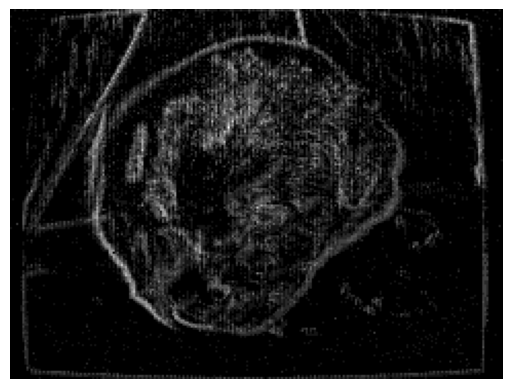

In [81]:
plt.imshow(np.mean(np.array(sample['events']), axis=0).reshape(180, 240), cmap='gray')
plt.axis('off')
plt.show()

## Define Model 

In [ ]:
spike_grad = surrogate.fast_sigmoid(slope=25)

class TinyConvSNN_24_FC(nn.Module):
    def __init__(self, H=48, W=48, n_classes=24, beta=0.95, num_steps=100, dropout_p=0.0, fc_hidden=512):
        super().__init__()
        self.H, self.W = H, W
        self.n_classes = n_classes
        self.num_steps = num_steps
        
        # Conv layer (L1)
        self.conv1 = nn.Conv2d(1, 4, kernel_size=5, stride=6, padding=0, bias=False)
        
        # Hidden layer (L2)
        self.fc1 = nn.Linear(256, fc_hidden, bias=False)  
        self.lif_fc1 = snn.Leaky(beta=beta, spike_grad=spike_grad, learn_beta=False)  
        self.dropout_fc1 = nn.Dropout(p=dropout_p)  
        
        # Readout layer (L3)
        self.readout = nn.Linear(fc_hidden, n_classes, bias=False)  
        
        # LIF neurons
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad, learn_beta=False)
        self.lif_out = snn.Leaky(beta=beta, spike_grad=spike_grad, learn_beta=False)
        
        self.dropout1 = nn.Dropout(p=dropout_p)
        self.dropout_readout = nn.Dropout(p=dropout_p)
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_normal_(m.weight, gain=1.0)
    
    def forward(self, x):
        T, B, _ = x.shape
        x = x.view(T, B, 1, self.H, self.W)
        
        mem1 = self.lif1.init_leaky().to(x.device)
        mem_fc1 = self.lif_fc1.init_leaky().to(x.device)  
        memo = self.lif_out.init_leaky().to(x.device)
        
        spk_out_rec = []
        for t in range(T):
            xt = x[t]
            # Conv layer
            cur1 = self.conv1(xt)
            spk1, mem1 = self.lif1(cur1, mem1)
            spk1 = self.dropout1(spk1)
            # Flatten
            feat = spk1.flatten(1)  # [B, 256]
            # Hidden FC layer 
            cur_fc1 = self.fc1(feat)
            spk_fc1, mem_fc1 = self.lif_fc1(cur_fc1, mem_fc1)
            spk_fc1 = self.dropout_fc1(spk_fc1)
            # Readout layer
            spk_fc1_drop = self.dropout_readout(spk_fc1)
            cur_out = self.readout(spk_fc1_drop)
            spk_out, memo = self.lif_out(cur_out, memo)
            
            spk_out_rec.append(spk_out)
        
        return torch.stack(spk_out_rec, dim=0)
    
    @torch.no_grad()
    def predict(self, x):
        # x: [T,B,2304]
        spk = self.forward(x)
        counts = spk.sum(0)              # [B,26]
        return counts.argmax(dim=1)